In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# import the data
df = pd.read_csv('D:/Study/IFRS-9-Complient-Risk-Analysis-modelling/data/merged_dataset.csv')
df = df.replace(-99999,np.nan)

### 4.1 — Missing Value Treatment

In [5]:
# Missing Value Summary

missing_df = (
    pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": (df.isnull().mean() * 100).round(2),
        "Data Type": df.dtypes
    })
    .query("`Missing Count` > 0")
    .sort_values("Missing %", ascending=False)
)

missing_df

,Missing Count,Missing %,Data Type
CC_utilization,47636,92.79,float64
PL_utilization,44435,86.56,float64
max_delinquency_level,35949,70.03,float64
time_since_recent_deliquency,35949,70.03,float64
time_since_first_deliquency,35949,70.03,float64
max_unsec_exposure_inPct,23178,45.15,float64
max_deliq_6mts,12890,25.11,float64
max_deliq_12mts,10832,21.10,float64
PL_enq_L12m,6321,12.31,float64
PL_enq,6321,12.31,float64


- We see that Column `CC_utilization` has 92.79% missing values, then `PL_utilization` has 86.56% missing values.
- Followed by three columns `max_delinquency_level`, `time_since_recent_deliquency`, `time_since_first_deliquency` having 70.03% missing data

- We see that the values are missing in relation to business concept, which is a strong hint that the values are not missing at random.

### Let us now check if missingness is random or there are some patterns

In [6]:
for col in missing_df.index:

    temp = pd.crosstab(
        df[col].isnull(),
        df["Approved_Flag"],
        normalize="index"
    ) * 100

    print("="*70)
    print(col)
    print(temp.round(2))

CC_utilization
Approved_Flag      P1     P2     P3     P4
CC_utilization                            
False           15.08  54.03  15.59  15.30
True            11.01  63.40  14.43  11.16
PL_utilization
Approved_Flag      P1     P2     P3     P4
PL_utilization                            
False           16.23  54.57  13.88  15.32
True            10.54  63.99  14.61  10.86
max_delinquency_level
Approved_Flag             P1     P2     P3     P4
max_delinquency_level                            
False                   9.38  48.66  21.39  20.56
True                   12.13  68.74  11.57   7.56
time_since_recent_deliquency
Approved_Flag                    P1     P2     P3     P4
time_since_recent_deliquency                            
False                          9.38  48.66  21.39  20.56
True                          12.13  68.74  11.57   7.56
time_since_first_deliquency
Approved_Flag                   P1     P2     P3     P4
time_since_first_deliquency                            
False  

### Business Insights:
- 1. Customers with no recorded credit card or personal loan utilization shows that they have never used their credit card out of limit, making the missing values meaningful rather than accidental.

- 2. All the features related to delinquency(missed payment), enquiries and unsecured exposure, shows that if data in these columns is missing shows that the consumer has never missed any monthly payment. That is Consumer are mostly flagged P4 if they have NO(i.e they have records of missed payments).

- **These are some critical understandings we could sense from this table**

### What to do NEXT: 
| Column Group              | Likely Type             | Decision            |
| ------------------------- | ----------------------- | ------------------- |
| CC_utilization            | MNAR / Business missing | Drop (>90% missing) |
| PL_utilization            | MNAR / Business missing | Drop (>80% missing) |
| Delinquency History       | MNAR / Business missing | Drop (70% missing)  |
| max_unsec_exposure_inPct  | MAR/MNAR                | Keep & Impute       |
| max_deliq_6mts            | MAR/MNAR                | Keep & Impute       |
| max_deliq_12mts           | MAR/MNAR                | Keep & Impute       |
| Enquiry Variables         | MAR/MNAR                | Keep & Impute       |
| time_since_recent_payment | MAR                     | Median Imputation   |
| Age Variables             | MCAR (practically)      | Median Imputation   |


### ***We will use three different techniques to impute or drop the required columns***

- 1. Drop the columns having missing data > 70%
- 2. Impute the columns with business meaning by 0.
- 3. Impute the rest of the columns with Median Imputation

### 4.2 Missing Value Treatment

**1. Dropping High Missing Value Columns**

In [7]:
# Columns to drop (>70% missing)

drop_cols = [
    "CC_utilization",
    "PL_utilization",
    "max_delinquency_level",
    "time_since_recent_deliquency",
    "time_since_first_deliquency"
]

df.drop(columns=drop_cols, inplace=True)

print("Remaining Shape:", df.shape)

Remaining Shape: (51336, 82)


**2. Imputing With 0**

In [8]:
zero_impute_cols = [
    "max_deliq_6mts",
    "max_deliq_12mts",
    "PL_enq",
    "PL_enq_L6m",
    "PL_enq_L12m",
    "CC_enq",
    "CC_enq_L6m",
    "CC_enq_L12m",
    "tot_enq",
    "enq_L3m",
    "enq_L6m",
    "enq_L12m",
    "time_since_recent_enq"
]

df[zero_impute_cols] = df[zero_impute_cols].fillna(0)

This is business-driven imputation, which is stronger than blindly using the median.

**Median Value Imputation**

In [ ]:
median_impute_cols = [
    "max_unsec_exposure_inPct",
    "time_since_recent_payment",
    "pct_currentBal_all_TL",
    "Age_Oldest_TL",
    "Age_Newest_TL"
]

for col in median_impute_cols:
    df[col].fillna(df[col].median(), inplace=True)

Median is robust to outliers and is suitable for continuous numerical variables where a missing value doesn't have an obvious business meaning.

### Final Null value count

In [11]:
df.isnull().sum().sum()

np.int64(0)

In [58]:
### Let us save this dataset for later use
df.to_csv('D:/Study/IFRS-9-Complient-Risk-Analysis-modelling/data/missing_handled_dataset.csv',index=False)

### 4.3 Outlier Treatment

In [59]:
df = pd.read_csv('D:/Study/IFRS-9-Complient-Risk-Analysis-modelling/data/missing_handled_dataset.csv')
print(df.shape)

(51215, 82)


**4.3.1 Detect Outliers Using IQR Method**

In [17]:
num_cols = df.select_dtypes(include=('number')).columns.to_list()
# Detect Outliers Using IQR Method

outlier_summary = []

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_percentage = round((outlier_count / len(df)) * 100, 2)

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": outlier_count,
        "Outlier %": outlier_percentage,
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2)
    })

outlier_df = (
    pd.DataFrame(outlier_summary)
      .sort_values("Outlier %", ascending=False)
      .reset_index(drop=True)
)

outlier_df

,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,max_unsec_exposure_inPct,15623,30.43,0.61,3.10
1,num_std_6mts,11316,22.04,-1.50,2.50
2,PL_enq_L6m,11100,21.62,0.00,0.00
3,pct_PL_enq_L6m_of_L12m,11100,21.62,0.00,0.00
4,pct_PL_enq_L6m_of_ever,11100,21.62,0.00,0.00
...,...,...,...,...,...
72,PROSPECTID,0,0.00,-25666.50,77003.50
73,pct_tl_open_L12M,0,0.00,-1.12,1.88
74,pct_of_active_TLs_ever,0,0.00,-0.88,2.12
75,pct_opened_TLs_L6m_of_L12m,0,0.00,-0.96,1.61


- We already know that our data is mostly right skewed with many outliers but even the outlier data is genuine and highly contextual with our work.

**We will visually inspect the continuous columns for further investigation**

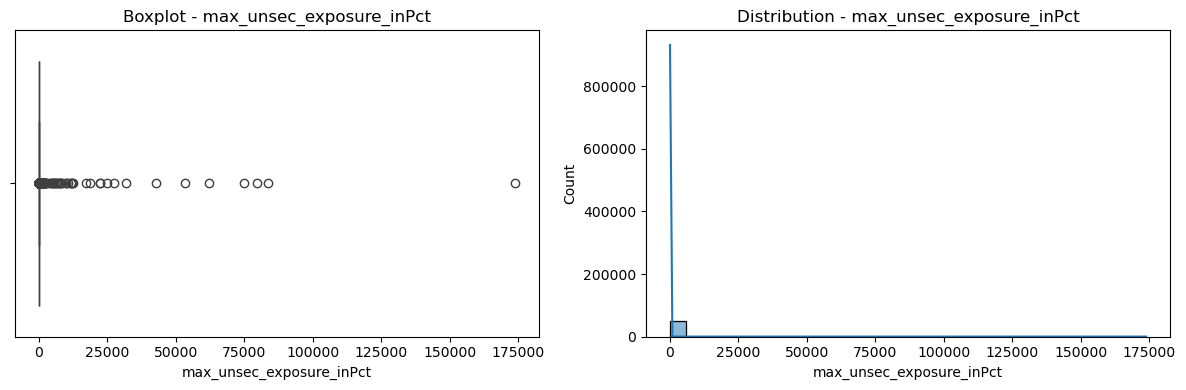

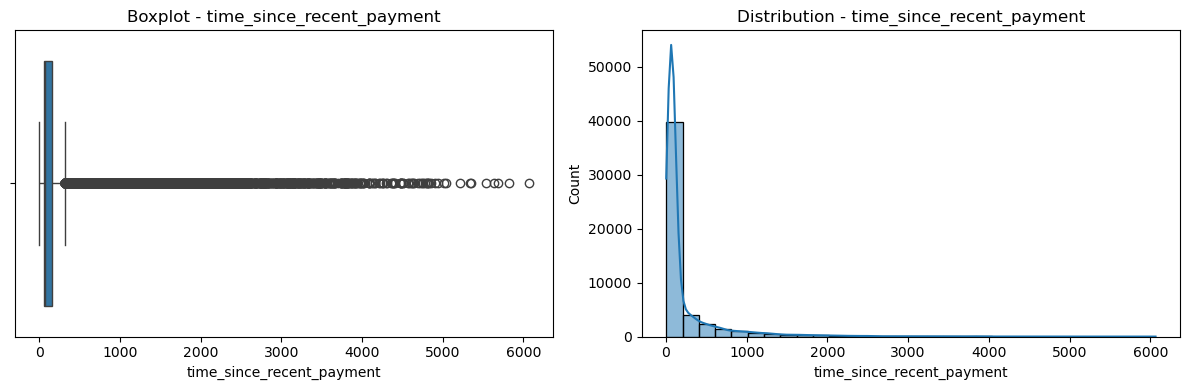

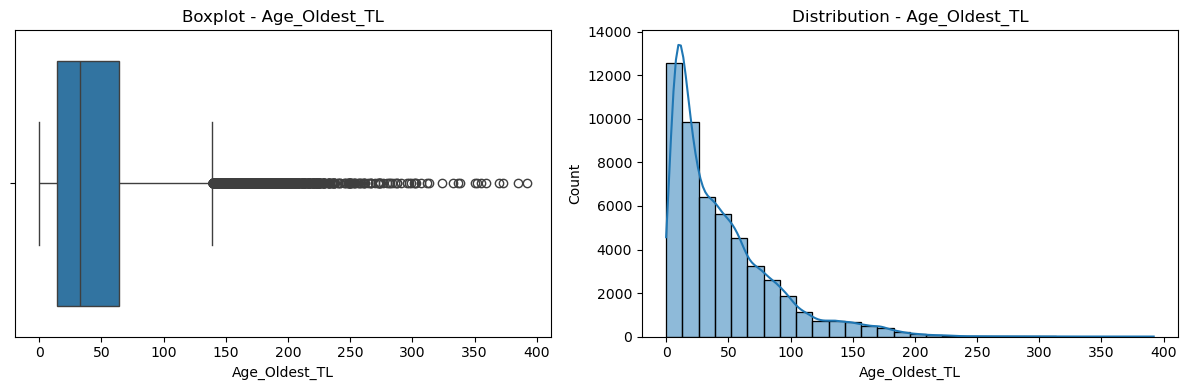

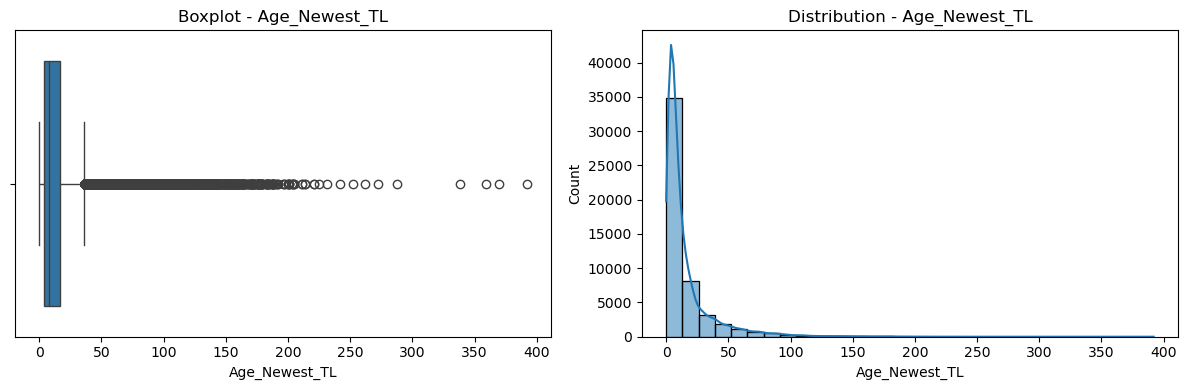

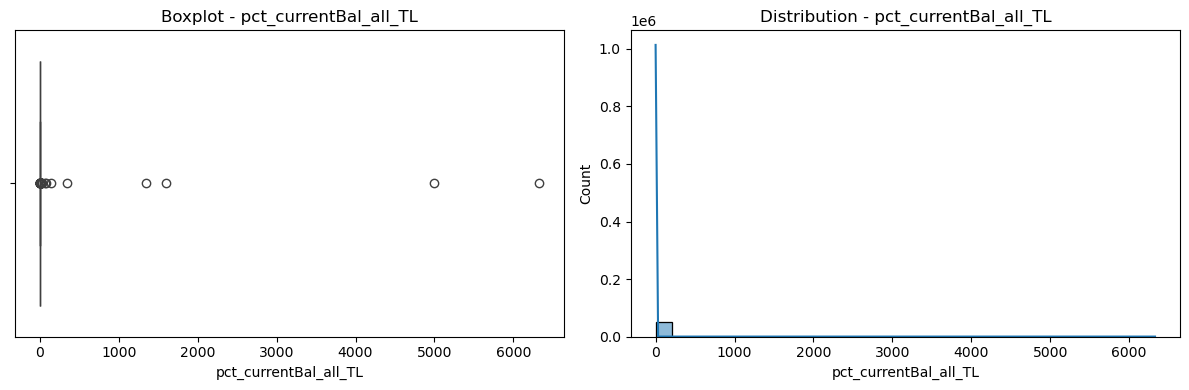

In [18]:
continuous_cols = [
    "max_unsec_exposure_inPct",
    "time_since_recent_payment",
    "Age_Oldest_TL",
    "Age_Newest_TL",
    "pct_currentBal_all_TL"
]

for col in continuous_cols:

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(x=df[col], ax=ax[0])
    ax[0].set_title(f"Boxplot - {col}")

    sns.histplot(df[col], bins=30, kde=True, ax=ax[1])
    ax[1].set_title(f"Distribution - {col}")

    plt.tight_layout()
    plt.show()

- NOTICE:
- 1. Column `max_unsec_exposure_inPct` column should show maximum unsecured exposure in percentage but the values goes as high as 175000. We must look into it.

### Deep Dive into Investigation

In [19]:
df["max_unsec_exposure_inPct"].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])

count     51336.000000
mean         22.029210
std        1110.284497
min           0.000000
25%           1.542000
50%           1.820000
75%           2.164250
90%           7.500000
95%          13.250000
99%          33.913600
max      173800.000000
Name: max_unsec_exposure_inPct, dtype: float64

- See that even 99 percentile values are under 33.91 but somehow Top 1% values goes upto 173800

In [20]:
df["max_unsec_exposure_inPct"].nlargest(20)

29033    173800.000
49204     83672.100
21446     79527.125
6063      75000.000
91        62083.333
34457     53333.333
35611     42656.600
391       31983.333
37228     27590.000
46932     25000.000
42963     22444.111
36848     22290.000
11027     18750.000
3773      17276.667
13201     12703.846
38373     12000.000
36033     11904.762
1482      11828.400
48980     10541.583
10564     10000.000
Name: max_unsec_exposure_inPct, dtype: float64

In [21]:
df["max_unsec_exposure_inPct"].value_counts().head(20)


max_unsec_exposure_inPct
1.820     23184
0.000       581
0.001       145
1.000       144
5.000       121
10.000      121
2.000       114
2.500        97
0.500        92
3.333        88
0.600        86
6.667        86
0.800        75
0.750        75
1.500        74
1.667        70
4.000        69
0.400        64
1.200        63
0.833        60
Name: count, dtype: int64

In [22]:
df[df["max_unsec_exposure_inPct"] > 100][
    ["max_unsec_exposure_inPct", "Approved_Flag"]
].head(20)

,max_unsec_exposure_inPct,Approved_Flag
2,5741.667,P2
91,62083.333,P2
391,31983.333,P4
441,135.714,P2
582,849.200,P4
713,165.598,P2
1482,11828.400,P3
1498,169.103,P2
3536,2365.700,P2
3773,17276.667,P2


This does not show any odd distribution of Target categories.
**Let us check the values which are > 100**

In [23]:
(df["max_unsec_exposure_inPct"] > 100).sum()

np.int64(115)

In [24]:
round((df["max_unsec_exposure_inPct"] > 100).mean() * 100, 4)

np.float64(0.224)

- The best thing to do is to remove these 115 records, since they only are 0.224% of the entire dataset, and they do not club into one single category as well.

**Let us look at all the columns containing Pct and see if the same problem is there or not**

In [40]:
having_pct_df = outlier_df[outlier_df["Feature"].str.contains("pct", case=False)]
having_pct_df
# data of columns containing pct in the name

,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,max_unsec_exposure_inPct,15623,30.43,0.61,3.10
3,pct_PL_enq_L6m_of_L12m,11100,21.62,0.00,0.00
4,pct_PL_enq_L6m_of_ever,11100,21.62,0.00,0.00
5,pct_tl_closed_L6M,10473,20.40,-0.08,0.13
39,pct_CC_enq_L6m_of_ever,3935,7.67,0.00,0.00
41,pct_CC_enq_L6m_of_L12m,3935,7.67,0.00,0.00
42,pct_tl_open_L6M,3928,7.65,-0.46,0.77
47,pct_tl_closed_L12M,3293,6.41,-0.38,0.62
64,pct_currentBal_all_TL,49,0.10,-1.11,2.09
69,pct_active_tl,0,0.00,-0.88,2.12


In [42]:
for col in having_pct_df['Feature']:
    print()
    print('='*50)
    print(f'Column -> {col}')
    print(df[col].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

    # print("\nLargest Values:")
    # print(df[col].nlargest(20))

    # print("\nRows > 100:")
    # print((df[col] > 100).sum())
    print('='*50)


Column -> max_unsec_exposure_inPct
count     51336.000000
mean         22.029210
std        1110.284497
min           0.000000
25%           1.542000
50%           1.820000
75%           2.164250
90%           7.500000
95%          13.250000
99%          33.913600
max      173800.000000
Name: max_unsec_exposure_inPct, dtype: float64

Column -> pct_PL_enq_L6m_of_L12m
count    51336.000000
mean         0.190414
std          0.376218
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
90%          1.000000
95%          1.000000
99%          1.000000
max          1.000000
Name: pct_PL_enq_L6m_of_L12m, dtype: float64

Column -> pct_PL_enq_L6m_of_ever
count    51336.000000
mean         0.170492
std          0.350209
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
90%          1.000000
95%          1.000000
99%          1.000000
max          1.000000
Name: pct_PL_enq_L6m_of_ever, dtype: float64

Column -> pct_tl_clos

This shows that we have to look at one more column named `pct_currentBal_all_TL`

In [44]:
print(df['pct_currentBal_all_TL'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

print("\nLargest Values:")
print(df['pct_currentBal_all_TL'].nlargest(20))

print("\nRows > 100:")
print((df['pct_currentBal_all_TL'] > 100).sum())

count    51336.000000
mean         0.835846
std         36.802321
min          0.000000
25%          0.089000
50%          0.618000
75%          0.888000
90%          1.000000
95%          1.032000
99%          1.235000
max       6327.500000
Name: pct_currentBal_all_TL, dtype: float64

Largest Values:
41860    6327.500
22427    5000.000
45911    1593.792
3133     1348.000
13773     338.347
23389     139.286
23673      76.638
51087      70.675
10478      23.154
31129      21.000
21688      20.000
1292       10.179
16378      10.000
26922      10.000
15226       9.024
10096       9.000
45287       8.963
23076       7.238
32814       7.190
35499       6.883
Name: pct_currentBal_all_TL, dtype: float64

Rows > 100:
6


- So finally, we have the indexes of the rows to remove

In [45]:
pct_cols = [
    "max_unsec_exposure_inPct",
    "pct_currentBal_all_TL"     
]
rows_to_remove = df[
    (df[pct_cols] > 100).any(axis=1)
].index

print(f"Number of rows to remove: {len(rows_to_remove)}")
print(rows_to_remove.tolist()[:20])   # First 20 indices

Number of rows to remove: 121
[2, 91, 391, 441, 582, 713, 1482, 1498, 3133, 3536, 3773, 4851, 6063, 6311, 7480, 8376, 8621, 8895, 8970, 9145]


### Removing the rows

In [ ]:
df = df.drop(index=rows_to_remove).reset_index(drop=True)

print("New Shape:", df.shape)

New Shape: (51215, 82)


In [61]:
print("=" * 50)
print("Dataset Shape")
print(df.shape)

print("\n" + "=" * 50)
print("Data Types")
print(df.dtypes.value_counts())

print("\n" + "=" * 50)
print("Missing Values")
print(df.isnull().sum().sum())

print("\n" + "=" * 50)
print("Duplicate Rows")
print(df.duplicated().sum())

print("\n" + "=" * 50)
print("Object Columns")
print(df.select_dtypes(include="object").columns.tolist())

Dataset Shape
(51215, 82)

Data Types
int64      46
float64    30
object      6
Name: count, dtype: int64

Missing Values
0

Duplicate Rows
0

Object Columns
['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']


### This is the end of this notebook. Next Step -> Column Encoding and then Feature Selection